In [1]:
import os
import json
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import utils2

In [6]:
PHENOTYPE_PATH = os.path.join(utils2.DATASET_PATH, 'phenotype', 'phenotype_preprocessed.tsv')
HOLDOUTS30_PATH = os.path.join(utils2.HOLDOUTS_PATH, '30_holdouts_new')
SUBJECTS_PATH = os.path.join(utils2.DATASET_PATH, 'sub-*')
CONTRAST_NAME = 'incongruent_vs_congruent'
ALT_TEST = 'Incongruent > Congruent'
ALPHA1 = 0.01
ALPHA2 = 0.05
ALPHA3 = 0.1
HEIGHT_CONTROL1 = 'fpr'
HEIGHT_CONTROL2 = 'fdr'
CLUSTER_THRESHOLD1 = 10
CLUSTER_THRESHOLD2 = 20
CLUSTER_THRESHOLD3 = 25
CLUSTER_THRESHOLD4 = 30
ATLAS1 = 'schaefer'
N_ROIS1 = 1000
YN1 = 17
FEATURE_TABLE_NAME = 'ML_Dataset'
CONSENSUS_THRESHOLDS = [0.7, 0.8, 0.9]

In [3]:
# --- paths for logging and consensus tracking ----------------------------------
LOG_PATH = os.path.join(HOLDOUTS30_PATH, 'iteration_log.jsonl')
ROI_COUNTS_PATH = os.path.join(HOLDOUTS30_PATH, 'roi_occurrence.json')
CONSENSUS_ROIS_PATH = os.path.join(HOLDOUTS30_PATH, 'threshold_wise_consensus_rois.json')

In [4]:
holdouts_info = utils2.load_file(HOLDOUTS30_PATH, 'holdouts30_split_ids.json')
phenotype = pd.read_csv(PHENOTYPE_PATH, delimiter='\t')

Resuming... 0 valid iterations already completed
Alpha: 0.01, Height control: fpr, Cluster threshold: 20
0 unique ROIs seen so far

Holdout ID: 01
Computed group mean task-fmri
Subjects completed:
24139, 24212, 22956, 23910, 22354, 22268, 24151, 23996, 21214, 24073, 23749, 22353, 23483, 23979, 22477, 23353, 23883, 23494, 24015, 23362, 23261, 24033, 23855, 23972, 23014, 23568, 22487, 23532, 24004, 24021, 24353, 23376, 23971, 23865, 23762, 24240, 22630, 23442, 22871, 22587, 20131, 22818, 23010, 24089, 23631, 24067, 24145, 24038, 24017, 22734, 20725, 23878, 23545, 23407, 24091, 23534, 24236, 22873, 22380, 22475, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


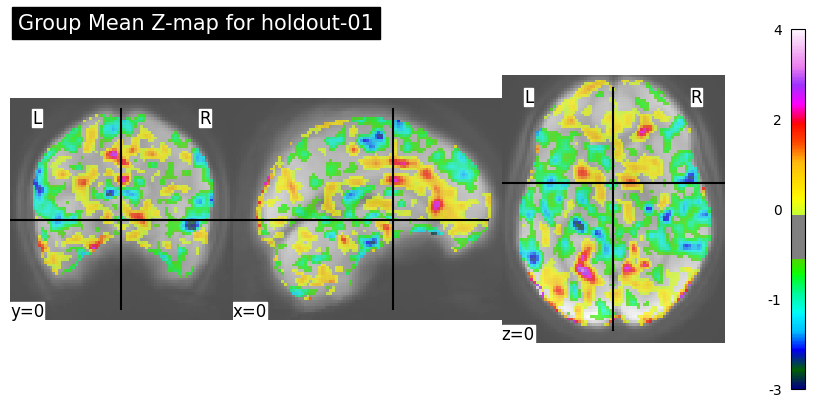

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


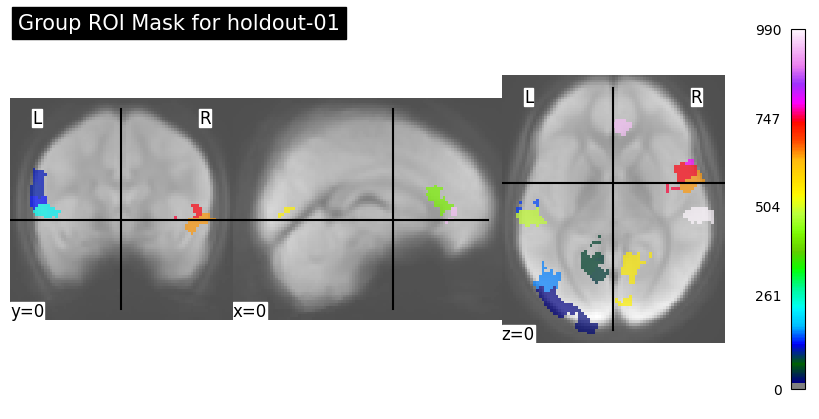

138 ROIs found
Subjects completed:
22829, 22831, 22847, 22860, 22862, 22906, 23028, 23044, 23072, 23123, 23257, 23294, 23303, 23314, 23317, 23342, 23381, 23382, 23386, 23392, 23432, 23480, 23485, 23501, 23524, 23559, 23567, 23572, 23584, 23601, 23622, 23629, 23664, 23690, 23735, 23779, 23822, 23842, 23871, 23892, 23923, 23925, 23946, 23985, 23986, 23987, 23991, 24022, 24029, 24039, 24040, 24046, 24050, 24106, 24115, 24118, 24127, 24142, 24146, 24148, 24182, 24197, 24198, 24217, 24260, 24270, 24275, 24276, 24300, 22172, 20209, 21100, 21508, 22281, 22286, 22295, 22346, 22365, 22366, 22381, 22482, 22494, 22532, 22536, 22600, 22623, 22686, 22687, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 9592)


,participant_id,LH_VisCent_ExStr_1,LH_VisCent_ExStr_2,LH_VisCent_ExStr_3,LH_VisCent_ExStr_7,LH_VisCent_ExStr_9,LH_VisCent_ExStr_12,LH_VisCent_ExStr_14,LH_VisCent_ExStr_16,LH_VisCent_ExStr_17,...,RH_DefaultA_PFCm_7_to_RH_DefaultA_PFCm_9,RH_DefaultA_PFCm_7_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_7_to_RH_TempPar_12,RH_DefaultA_PFCm_7_to_RH_TempPar_19,RH_DefaultA_PFCm_9_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_9_to_RH_TempPar_12,RH_DefaultA_PFCm_9_to_RH_TempPar_19,RH_DefaultC_IPL_2_to_RH_TempPar_12,RH_DefaultC_IPL_2_to_RH_TempPar_19,RH_TempPar_12_to_RH_TempPar_19
33,sub-023690,-0.10149364933693102,-0.003845710555210282,-0.3387468896925771,0.27017930835291876,0.18747795329912917,0.31782091619770453,0.20022335347390255,0.40077393332591943,-0.29570471435586493,...,0.2619893732306568,-0.0004429575370195843,-0.052823149385636585,0.035630251291835516,-0.02614978470762235,-0.0956507413712422,-0.013270565211851899,0.11769559270238648,0.08610992516365652,0.16406999631138033
3,sub-022860,0.04559622199356706,-0.10434387076038833,-0.025483781240495697,-0.6631774963028746,-0.10162930631273626,-0.12564615430919854,-0.21860483812383188,-0.1324555025436808,-0.33043571431459384,...,0.018765835784016995,-0.0073223622429155035,-0.020061882555485452,0.024759882581087675,0.07236320852742253,0.05724034688115914,0.0821023770884268,0.017638657332027914,-0.08397026205633272,0.1662206839534193
75,sub-022295,1.1600669260900924,1.2608332566367844,0.867401012429738,0.660478606856642,0.015136568733459381,-0.4002581134961492,-0.009724384454118372,0.6096185834944097,-0.17037517127988044,...,0.16904276706876947,-0.010963377581943575,0.00977910898446713,-0.0184672932484728,0.04646927950428547,-0.0058159323380832725,0.020449212911100825,-0.015087615738899577,0.06330601065182678,0.054477515880481164
84,sub-022600,-0.5160287309199016,-0.35074508644562835,0.10141042149237384,0.41080537990963384,0.4418023783550996,0.6008784303057844,0.5975423241670108,0.18453625877385177,-0.32801045065001244,...,0.13669328947302262,0.021663341687362506,0.019762383523213058,0.0057557200797661145,0.0802717229825812,-0.031592303811183886,0.03311598760706621,0.031004773041179143,0.01029242200848963,0.012496815674220113
85,sub-022623,0.04645566537449275,-0.03163482996474846,-0.14839575863637458,-0.07513911945701071,0.24300459133434693,0.39449876244517484,0.2750035762217621,0.132674026395023,0.18884650822604615,...,-0.017157469298719988,-0.013187014651245313,0.15802119446885216,0.04297965884710802,0.036091581248700606,0.027597886765705106,0.012725357254690555,0.0588244989495059,-0.0629383914344333,-0.0032039127139926325



Holdout ID: 02
Computed group mean task-fmri
Subjects completed:
23480, 22630, 23123, 23892, 23392, 22286, 24300, 20725, 24127, 23690, 23353, 22268, 22871, 24142, 24240, 22734, 24276, 23925, 23822, 23376, 24021, 22477, 22829, 22831, 24029, 23946, 22818, 22536, 24270, 23601, 24040, 23381, 23735, 24089, 22281, 23923, 23382, 22532, 23762, 23878, 23971, 23386, 23567, 24212, 24039, 21100, 24260, 22354, 23494, 22600, 22494, 23972, 24022, 23014, 23342, 24017, 22587, 24145, 23072, 23545, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


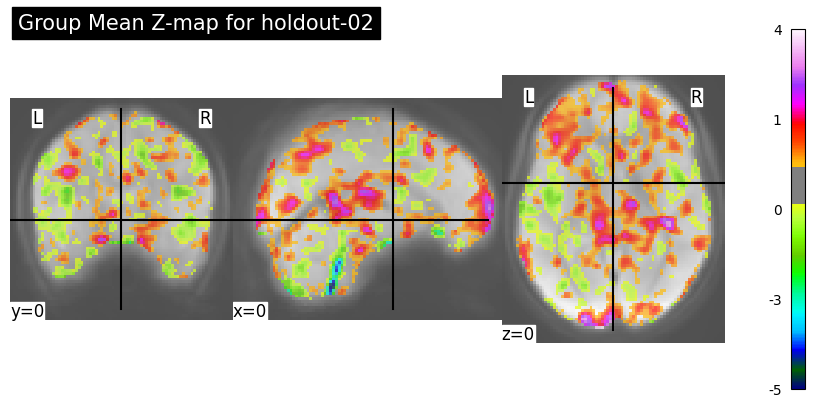

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


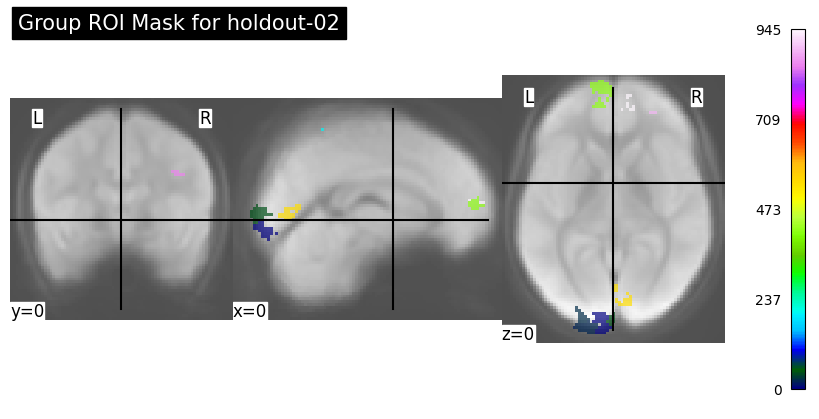

40 ROIs found
Subjects completed:
22847, 22860, 22862, 22873, 22906, 22956, 23010, 23028, 23044, 23257, 23261, 23294, 23303, 23314, 23317, 23362, 23407, 23432, 23442, 23483, 23485, 23501, 23524, 23532, 23534, 23559, 23568, 23572, 23584, 23622, 23629, 23631, 23664, 23749, 23779, 23842, 23855, 23865, 23871, 23883, 23910, 23979, 23985, 23986, 23987, 23991, 23996, 24004, 24015, 24033, 24038, 24046, 24050, 24067, 24073, 24091, 24106, 24115, 24118, 24139, 24146, 24148, 24151, 24182, 24197, 24198, 24217, 24236, 24275, 24353, 22172, 20131, 20209, 21214, 21508, 22295, 22346, 22353, 22365, 22366, 22380, 22381, 22475, 22482, 22487, 22623, 22686, 22687, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 821)


,participant_id,LH_VisCent_Striate_1,LH_VisCent_Striate_2,LH_VisCent_Striate_3,LH_VisCent_Striate_4,LH_VisCent_ExStr_8,LH_VisCent_ExStr_10,LH_VisCent_ExStr_13,LH_VisCent_ExStr_19,LH_VisCent_ExStr_21,...,RH_ContB_PFClv_8_to_RH_DefaultA_PFCm_6,RH_ContB_PFClv_8_to_RH_DefaultA_PFCm_8,RH_ContB_PFClv_8_to_RH_DefaultB_PFCd_1,RH_ContB_PFClv_8_to_RH_DefaultB_PFCd_2,RH_DefaultA_PFCm_6_to_RH_DefaultA_PFCm_8,RH_DefaultA_PFCm_6_to_RH_DefaultB_PFCd_1,RH_DefaultA_PFCm_6_to_RH_DefaultB_PFCd_2,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCd_1,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCd_2,RH_DefaultB_PFCd_1_to_RH_DefaultB_PFCd_2
80,sub-022380,1.995059288209354,1.5955387026266135,1.3740725412875114,0.19568998199427462,0.8449983644558235,1.0726201243612208,0.5359492425684467,0.16425044797050967,0.7570050737336493,...,0.1521672814640128,-0.07552963336069737,0.10940922925378992,0.02858210604303047,0.23829784033049445,0.2126555281730433,0.029836665055997087,0.24807969829557472,0.5076272004229582,0.12265901966901796
2,sub-022862,0.41538574588516747,0.02492103972463725,0.1501819699756768,-0.0019987898505007817,1.0556925192206146,1.5326767338061023,0.061735106358087495,0.016524875614429713,0.13890087653363148,...,0.32477094897123643,-0.22120453912668922,0.27029064473222075,0.0499676004807183,0.055139061375038954,0.16083900265654635,-0.1657581494532683,0.17471007591181453,0.44860111951181897,0.39522031327788
74,sub-021508,0.24115913103109185,0.6542121306824247,0.042926624422019846,0.0,-0.2427924591306933,0.030728317582897534,0.20196638463459657,0.19586985156906256,0.38187715778634446,...,-0.10186589416759208,0.15020247641682385,0.5030616202463727,0.1407087431144495,0.19143734864591083,-0.1510436716528035,0.12482831362303778,0.04203983401253659,0.18430353833527136,0.2734257526183004
1,sub-022860,-0.31928974279749783,0.09267571843797907,-0.16476362277668521,-0.005630769321839551,0.14459007516606667,0.5529124065381427,0.15520302823699875,0.02595079584534443,0.1971971977675905,...,0.16233069381437013,-0.0027611488604340215,0.13946181153235493,0.12112664928127247,-0.01706773146413797,0.24604293296492183,0.3215731808666522,0.15450602136773278,0.20557050093096688,0.1387869233269595
81,sub-022381,-1.118900594041659,-0.37682827241535427,-0.545229740221549,0.010550098173130679,-0.3891288279441482,-0.6900337970699547,-0.7617012482649269,-0.22881027455966227,-0.46482589868338625,...,0.13255302308258354,0.1266378785255337,0.36658123344473176,0.03593663059051476,0.09878206525641371,0.2506296007531708,-0.27819871376301936,-0.01564343431158536,0.4928831022246162,0.12858723296607386



Holdout ID: 03
Computed group mean task-fmri
Subjects completed:
23044, 23342, 23314, 24089, 23559, 24004, 23883, 23735, 22906, 23532, 24240, 24145, 22354, 24115, 24275, 22346, 23925, 22532, 22871, 24091, 20209, 24021, 24353, 23601, 22536, 24276, 22381, 23923, 22686, 23972, 23317, 23392, 23386, 22831, 20131, 23534, 21508, 23257, 23892, 22487, 23572, 24236, 24039, 22380, 22687, 23779, 24146, 23690, 24106, 21100, 24127, 24217, 23987, 23568, 24139, 24151, 23303, 23631, 23842, 24029, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


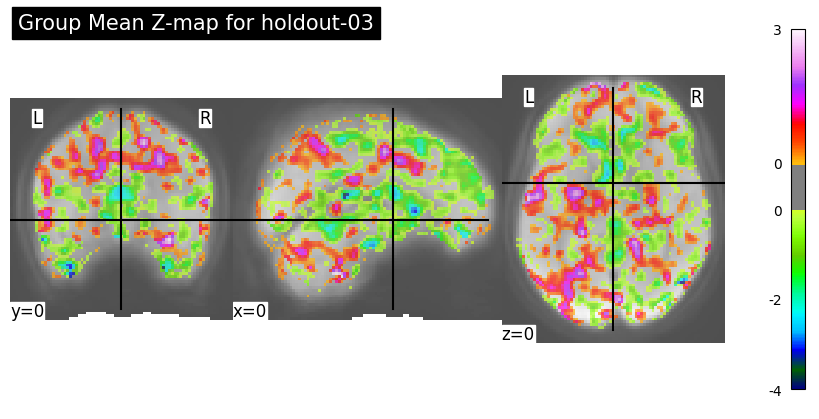

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


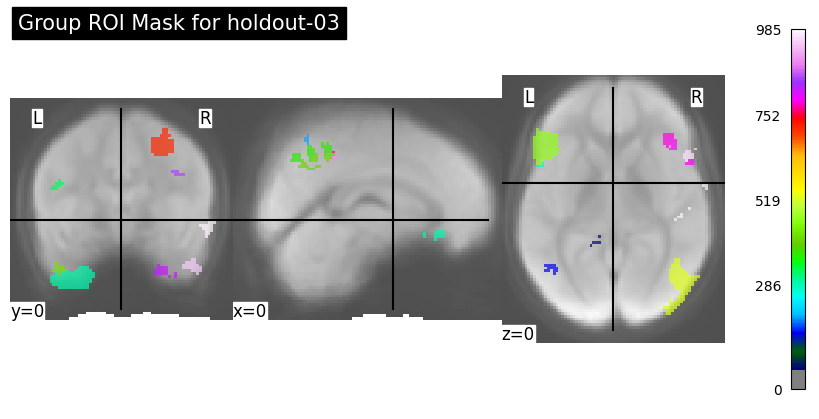

125 ROIs found
Subjects completed:
22734, 22818, 22829, 22847, 22860, 22862, 22873, 22956, 23010, 23014, 23028, 23072, 23123, 23261, 23294, 23353, 23362, 23376, 23381, 23382, 23407, 23432, 23442, 23480, 23483, 23485, 23494, 23501, 23524, 23545, 23567, 23584, 23622, 23629, 23664, 23749, 23762, 23822, 23855, 23865, 23871, 23878, 23910, 23946, 23971, 23979, 23985, 23986, 23991, 23996, 24015, 24017, 24022, 24033, 24038, 24040, 24046, 24050, 24067, 24073, 24118, 24142, 24148, 24182, 24197, 24198, 24212, 24260, 24270, 24300, 22172, 20725, 21214, 22268, 22281, 22286, 22295, 22353, 22365, 22366, 22475, 22477, 22482, 22494, 22587, 22600, 22623, 22630, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 7876)


,participant_id,LH_VisCent_ExStr_2,LH_VisCent_ExStr_6,LH_VisCent_ExStr_7,LH_VisCent_ExStr_29,LH_VisCent_ExStr_30,LH_VisPeri_ExStrInf_1,LH_VisPeri_ExStrInf_2,LH_VisPeri_ExStrInf_9,LH_SomMotA_15,...,RH_DefaultC_PHC_2_to_RH_TempPar_3,RH_DefaultC_PHC_2_to_RH_TempPar_5,RH_DefaultC_PHC_2_to_RH_TempPar_6,RH_DefaultC_PHC_2_to_RH_TempPar_7,RH_TempPar_3_to_RH_TempPar_5,RH_TempPar_3_to_RH_TempPar_6,RH_TempPar_3_to_RH_TempPar_7,RH_TempPar_5_to_RH_TempPar_6,RH_TempPar_5_to_RH_TempPar_7,RH_TempPar_6_to_RH_TempPar_7
20,sub-023407,-0.43296142613675115,-0.29107732725303925,0.13511542889761985,0.06098940400810687,-0.47491965642058354,-0.1928865889334712,0.6046789341542281,0.26749752131254356,-0.20694202952631136,...,-0.07368909649078523,0.07850294868627536,-0.05119177985308144,-0.10552512181002097,0.1322838332423922,-0.012143249969647087,0.06244585594689469,0.1540947529597638,0.030857852693363327,0.12443591064919618
37,sub-023822,1.6020160415815374,0.9197910231791548,0.5692397683161196,0.1252644715059668,-0.054577148736543936,1.4196936374302174,0.272512384529933,0.21451643947736654,-1.6733064292255455,...,-0.056403588847649525,0.05416500268610894,-0.08909953249610698,-0.03182945095964459,0.22381997553639107,0.17592801269070446,0.21594009913950135,0.11020244681916032,-0.12950172998623743,0.3400668907141736
32,sub-023622,-0.5807194112561755,0.1787136987372503,-0.5385999347267111,-0.6060101657025475,-0.013397918086910376,0.09536416216289506,0.6336085238986673,0.34639945060165106,0.5191649026459639,...,-0.04728193598977982,0.05756676600139097,0.013396181655629124,-0.018965899357989938,0.12692541055141404,0.12088590768988881,0.12533474614418663,0.19203674129180007,-0.059519702117383555,0.23946389870694787
81,sub-022477,-1.3055124899186215,-1.4508140662749012,-0.24987998353323276,-1.2840681804327037,-1.2626788986712394,-1.020175005459228,-0.8399628414140442,-0.019391128216459264,0.9667933337839025,...,0.05617579319310067,-0.004350998540959233,-0.11004051289951026,0.03586510510497923,0.1619758037711211,0.10381140331848708,-0.10175510273841515,0.16256303333871525,0.02188274825527578,0.07983292583430625
73,sub-022268,-0.17759003879353058,-0.9400350719290399,0.260671586647023,-0.1030093619512172,0.10692871191862152,-0.2229852280282116,-0.559236887640115,0.6171185612940822,0.2705596875994508,...,0.12493244705005953,-0.05339791865259069,-0.06294626663097319,-0.15053002601798066,0.12438889372343778,0.2181545708083623,0.02749717676324131,0.2907989399812577,-0.005425587607908324,0.1205472547454394



Holdout ID: 04
Computed group mean task-fmri
Subjects completed:
23855, 22494, 23442, 24106, 21100, 23123, 22831, 20725, 23910, 23842, 23622, 22536, 22623, 24146, 23501, 22687, 22381, 24142, 22587, 22600, 23532, 22956, 22366, 22365, 22354, 24197, 24240, 23480, 22727, 23991, 24089, 22172, 24270, 22487, 24073, 24145, 23735, 23629, 24091, 24148, 23985, 23762, 23257, 23572, 23014, 22847, 24198, 23878, 23381, 22686, 24039, 23749, 24017, 22286, 23690, 23883, 24300, 24217, 23567, 23925, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


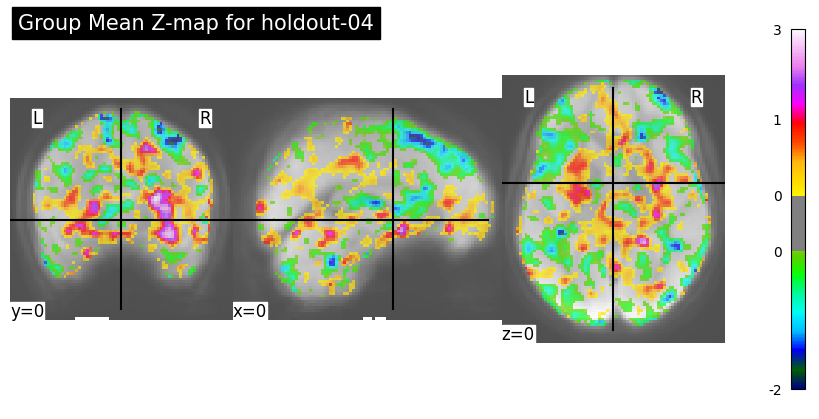

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


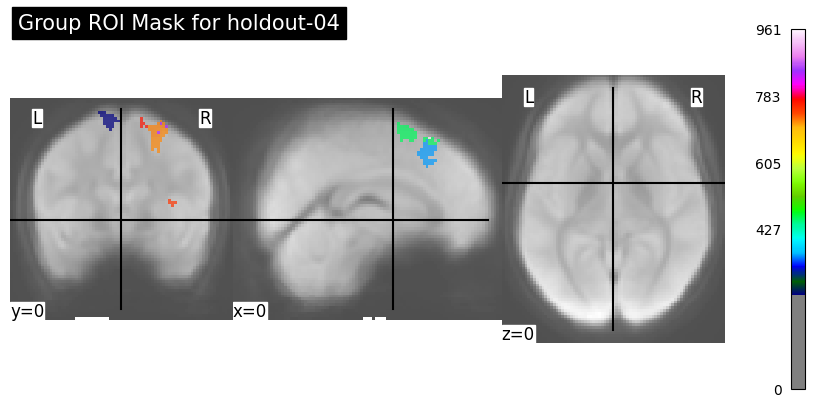

37 ROIs found
Subjects completed:
22734, 22818, 22829, 22860, 22862, 22871, 22873, 22906, 23010, 23028, 23044, 23072, 23261, 23294, 23303, 23314, 23317, 23342, 23353, 23362, 23376, 23382, 23386, 23392, 23407, 23432, 23483, 23485, 23494, 23524, 23534, 23545, 23559, 23568, 23584, 23601, 23631, 23664, 23779, 23822, 23865, 23871, 23892, 23923, 23946, 23971, 23972, 23979, 23986, 23987, 23996, 24004, 24015, 24021, 24022, 24029, 24033, 24038, 24040, 24046, 24050, 24067, 24115, 24118, 24127, 24139, 24151, 24182, 24212, 24236, 24260, 24275, 24276, 24353, 20131, 20209, 21214, 21508, 22268, 22281, 22295, 22346, 22353, 22380, 22475, 22477, 22482, 22532, 22630, 
Created ML Features table
Shape of ML Dataset: (89, 704)


,participant_id,LH_SalVentAttnA_ParMed_4,LH_SalVentAttnA_ParMed_7,LH_SalVentAttnA_FrMed_7,LH_ContB_PFCmp_2,LH_DefaultB_IPL_2,LH_DefaultB_IPL_5,LH_DefaultB_PFCd_9,LH_DefaultB_PFCd_11,LH_TempPar_10,...,RH_DefaultA_IPL_2_to_RH_DefaultA_IPL_4,RH_DefaultA_IPL_2_to_RH_DefaultA_IPL_7,RH_DefaultA_IPL_2_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_2_to_RH_DefaultB_PFCd_8,RH_DefaultA_IPL_4_to_RH_DefaultA_IPL_7,RH_DefaultA_IPL_4_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_4_to_RH_DefaultB_PFCd_8,RH_DefaultA_IPL_7_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_7_to_RH_DefaultB_PFCd_8,RH_DefaultB_PFCd_7_to_RH_DefaultB_PFCd_8
82,sub-022353,-1.0197047777660788,-0.6103235213429201,0.21341113509395562,0.3520358598062075,-0.528475305044074,-0.4530793690203347,-0.6948251563699703,-0.9313638016151012,-1.499325202355824,...,0.2785562522255909,-0.08138532046463681,0.153123716560026,-0.09825892585820233,0.27929848938153395,0.17274025753346758,-0.1167388751428925,-0.009025329861053462,-0.015220941010774282,0.10194555148735164
50,sub-023996,1.0541192810541002,1.0528885310290563,0.5242204585329986,1.8834145959295294,-0.7515925583804004,1.1666588983620414,2.3478444501786067,2.7388622489684993,0.6135448898815216,...,0.3042246654144009,0.11843644776155662,0.08921927826557105,0.0049924225283042405,0.2800324019810078,-0.17570909757558031,0.244421472716453,-0.0017715832942556313,-0.2217126883495306,0.34714889357703277
61,sub-024067,0.18015553076511043,0.2548329804184516,-0.39011964072406397,0.791809589588496,-0.6421093416356396,0.24783819302059723,0.5737288420242027,0.2822777993425114,-0.32468840893804113,...,0.497958954515226,0.10603445906693201,0.07052302218440197,-0.0053558610197490045,0.124749284531614,0.02445529140220793,-0.06336899566685254,0.23628596471024624,0.07413045792754747,0.40432308188892424
23,sub-023392,-0.9263401214865207,-0.5599017969323775,-0.30655484072262085,0.02271228105658712,-0.592704461193783,0.08029077403165982,-0.8582070650645024,-0.979798167520091,-0.36445752124842223,...,0.4649412751242642,0.01233521274657493,0.01865638514917177,0.030823864208999616,0.2988912686512599,-0.050211218861572024,-0.0718585999474446,-0.08960039540093392,-0.06188126114559695,0.41045607679849644
76,sub-021214,-0.8438059009793806,-1.3229934704904511,-0.18296816712210381,0.4370563594037174,-0.5069941823575826,-0.4077850573619778,-0.5181912700027882,-0.01876679375087307,-0.5367428427792922,...,0.3959593494505074,-0.008684102077116817,-0.08968818932515611,0.10597141085075913,0.24701054702594408,0.16684210659022422,-0.015389789134221432,0.15362668986268727,-0.026909321568728987,0.4022220314025974



Holdout ID: 05
Computed group mean task-fmri
Subjects completed:
23855, 23996, 23376, 24146, 21214, 23524, 23342, 23257, 22860, 24148, 23986, 23072, 23762, 22380, 24089, 23971, 23567, 23381, 23923, 23735, 22862, 23910, 22494, 23480, 23353, 23314, 22600, 23494, 24017, 24260, 24091, 24236, 24217, 24270, 23584, 23010, 24353, 22687, 23559, 24038, 23622, 23883, 23407, 23317, 24198, 22727, 23483, 24275, 22475, 23501, 22734, 21100, 23985, 24067, 22623, 23892, 22268, 23664, 22353, 23991, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


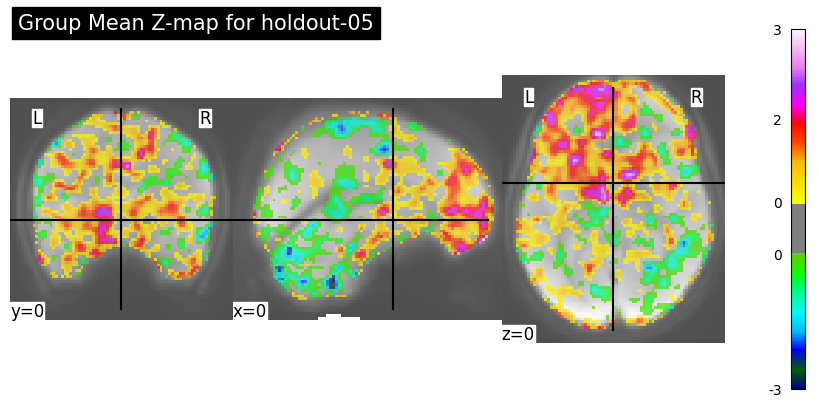

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


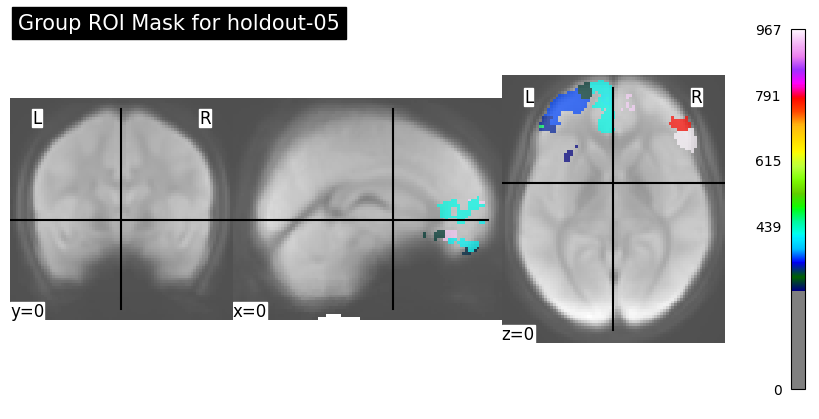

60 ROIs found
Subjects completed:
22818, 22829, 22831, 22847, 22871, 22873, 22906, 22956, 23014, 23028, 23044, 23123, 23261, 23294, 23303, 23362, 23382, 23386, 23392, 23432, 23442, 23485, 23532, 23534, 23545, 23568, 23572, 23601, 23629, 23631, 23690, 23749, 23779, 23822, 23842, 23865, 23871, 23878, 23925, 23946, 23972, 23979, 23987, 24004, 24015, 24021, 24022, 24029, 24033, 24039, 24040, 24046, 24050, 24073, 24106, 24115, 24118, 24127, 24139, 24142, 24145, 24151, 24182, 24197, 24212, 24240, 24276, 24300, 22172, 20131, 20209, 20725, 21508, 22281, 22286, 22295, 22346, 22354, 22365, 22366, 22381, 22477, 22482, 22487, 22532, 22536, 22587, 22630, 22686, 
Created ML Features table
Shape of ML Dataset: (89, 1831)


,participant_id,LH_SomMotA_4,LH_SomMotA_6,LH_SomMotA_11,LH_SomMotA_12,LH_SomMotA_13,LH_SomMotA_17,LH_SomMotA_19,LH_SomMotA_20,LH_SalVentAttnB_Ins_2,...,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_2,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_3,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_4,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_3,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_4,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_3_to_RH_DefaultB_PFCv_4,RH_DefaultB_PFCv_3_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_4_to_RH_DefaultB_PFCv_5
3,sub-022847,0.13492166530352864,-0.016579266291069417,0.2994711049219063,-0.21372115719012322,-0.6772642213191615,-0.3223084579295993,-0.9613718112298102,-1.0911757040116925,1.143462057751382,...,0.23874904600721078,-0.06998260798008349,0.0030030459955195984,0.012337556034902084,0.11603212033263162,0.22350551314950184,0.14788143114720512,0.019229444002652085,0.13185598472785684,0.26601648796589555
86,sub-022587,0.04631350436091302,-0.20730374995925366,-0.4785432931909212,-0.3050472732750073,-0.7439409695943517,-0.8171052312537268,-1.5073377470475384,-1.5715218062926066,0.4508202304343375,...,0.11984638482681491,0.09235016470051116,-0.04352450086753887,0.08113666849562685,0.2620270251407187,0.19679888603964246,0.023290513951571532,0.10938338517756634,0.07158419765699166,0.14874124327816673
32,sub-023779,0.15527473809594733,1.0582435466467401,1.0974985812604316,0.38898204154813587,0.45739830841141066,0.19258994768532636,0.9354874310982336,0.10744663261747411,-0.8586907566678998,...,0.1093122537750748,0.036553014632172136,0.055654519770249114,-0.12272838334596338,0.1287859329906397,0.2675892198386714,0.1781149713207753,0.057331739116828824,0.07332102429974809,0.1921230962244366
18,sub-023392,1.178462962827343,0.5166339053321957,0.8510789359398362,0.4998072362158998,1.5548237638644584,0.3278761662979504,0.44885164367421776,0.7444575985683127,0.7084645344265255,...,0.00025418385370090386,0.022346477893516944,0.0714828241872438,-0.05410470243933161,0.21754179197109427,0.06783195973925596,0.09768926621640248,0.23220702811683344,0.08685865228721547,0.327437928419146
17,sub-023386,-0.7128896652170081,-0.21317097158925968,-0.8115114263478228,-1.1453098140100295,-1.2192269690715003,-1.4292852714599797,-1.5609071093972144,-1.9987292448730742,-0.19096979936290076,...,-0.09937634987766834,0.165530352394833,0.08227016590686136,-0.10723017071167018,0.17572153048604433,0.13034868001503186,0.09371119900289417,0.32689519817215634,0.040697054063687586,0.4243398655401723




 --- Consensus ROI counts at current stage ---
Valid iterations count: 5
Total unique ROIs seen: 356

Threshold 70%: 0 consensus ROIs
Threshold 80%: 0 consensus ROIs
Threshold 90%: 0 consensus ROIs


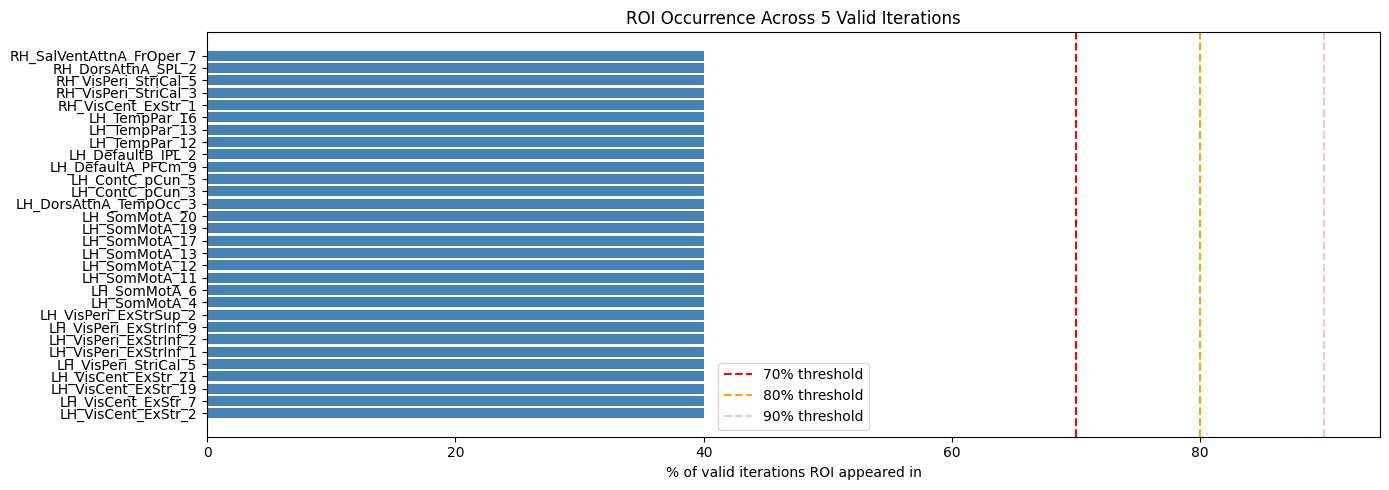

In [5]:
# --- load existing ROI occurrence counts if resuming ---------------------------
if os.path.exists(ROI_COUNTS_PATH):
    with open (ROI_COUNTS_PATH, 'r') as f:
        roi_occurrence = json.load(f)
else:
    roi_occurrence = {}

# --- load existing log to count valid iterations so far ------------------------
valid_iterations_count = 0
if os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if entry['valid']:
                valid_iterations_count += 1

print(f"Resuming... {valid_iterations_count} valid iterations already completed")
print(f"Alpha: {ALPHA1}, Height control: {HEIGHT_CONTROL1}, Cluster threshold: {CLUSTER_THRESHOLD2}")
print(f"{len(roi_occurrence)} unique ROIs seen so far\n")

# --- batch-wise iterations -----------------------------------------------------
batch = list(holdouts_info.items())[:5]

for key, val in batch:
    holdout_id = key.split('-')[1]
    feature_selection_config = {
        'alpha': ALPHA1,
        'height_control': HEIGHT_CONTROL1,
        'two-sided': True,
        'cluster_threshold':CLUSTER_THRESHOLD2
    }
    print(f"Holdout ID: {holdout_id}")

    # checking if holdout is done
    holdout_processed = False
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            for line in f:
                entry = json.loads(line)
                if (entry['holdout_id']==holdout_id and 
                   entry['feature_selection_config'] == feature_selection_config):
                    holdout_processed = True
                    break
            if holdout_processed:
                print(f"Holdout {holdout_id} already processed")
                continue
                    
    holdout_i_path = os.path.join(HOLDOUTS30_PATH, key)
    
    # --- ROI identification ----------------------------------------------------
    group_mean_tfmri, group_mean_task_zmap = utils2.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        has_all_confounds=True,
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )
    utils2.plot_map(
        'roi', group_mean_task_zmap,
        f"Group Mean Z-map for {key}", group_mean_tfmri
    )
    
    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils2.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        cluster_threshold=CLUSTER_THRESHOLD2,
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )
    utils2.plot_map(
        'roi', group_ROIs_mask,
        f"Group ROI Mask for {key}", group_mean_tfmri
    )

    # check iteration validity
    num_rois = len(group_ROIs_table)
    if num_rois == 0:
        print("[SKIP] No ROIs found\n")
        continue
    print(f"{num_rois} ROIs found")

    # --- update ROI occurrence counts ------------------------------------------
    roi_names = group_ROIs_table['label'].values.tolist()
    for roi in roi_names:
        roi_occurrence[roi] = roi_occurrence.get(roi, 0) + 1

    with open(ROI_COUNTS_PATH, 'w') as f:
        json.dump(roi_occurrence, f, indent=2)

    valid_iterations_count += 1

    # --- feature extraction ----------------------------------------------------
    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    ml_dataset = utils2.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        has_all_confounds=True,
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", 
        save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

    # --- log the iteration ---------------------------------------------------------
    log_entry = {
        'holdout_id': holdout_id,
        'n_rois_found': num_rois,
        'valid': num_rois>0,
        'feature_selection_config': feature_selection_config
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(log_entry) + '\n')

# --- consensus ROI plot after each batch ---------------------------------------
if valid_iterations_count > 0:
    ROIs_per_threshold = {t: [] for t in CONSENSUS_THRESHOLDS}
    print("\n --- Consensus ROI counts at current stage ---")
    print(f"Valid iterations count: {valid_iterations_count}")
    print(f"Total unique ROIs seen: {len(roi_occurrence)}\n")

    for threshold in CONSENSUS_THRESHOLDS:
        consensus_rois = [
            roi for roi, count in roi_occurrence.items()
            if count/valid_iterations_count >= threshold
        ]
        print(f"Threshold {int(threshold*100)}%: {len(consensus_rois)} consensus ROIs")
        ROIs_per_threshold[threshold] = consensus_rois

    with open(CONSENSUS_ROIS_PATH, 'w') as f:
        json.dump(ROIs_per_threshold, f, indent=2)

    # bar chart of top ROIs by occurrence
    sorted_rois = sorted(roi_occurrence.items(), key=lambda x: x[1], reverse=True)
    top_n = min(30, len(sorted_rois)) # show top 30 or fewer
    top_names = [r[0] for r in sorted_rois[:top_n]]
    top_counts = [r[1] for r in sorted_rois[:top_n]]
    top_percentages  = [c/valid_iterations_count*100 for c in top_counts]

    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.barh(top_names, top_percentages, color='steelblue')
    ax.axvline(x=70, color='red', linestyle='--', label='70% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', label='80% threshold')
    ax.axvline(x=90, color='pink', linestyle='--', label='90% threshold')
    ax.set_xlabel('% of valid iterations ROI appeared in')
    ax.set_title(f'ROI Occurrence Across {valid_iterations_count} Valid Iterations')
    ax.legend()
    plt.tight_layout()
    plt.show()